# Looking for correlations with affinity

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

df=pd.read_csv("data/all_affinity_data_with_predicted_metrics.csv")

print(f"Na values in affinity column {df["Affinity_nM"].isna().sum()}")
old_len=len(df)
df = df.dropna(subset=["Affinity_nM"])  # drop rows where 'binder' is NaN
print(f"dropped {len(df)-old_len} Na")
#df = df.dropna(subset=["binder"])  # drop rows where 'binder' is NaN
df['binder'] = df['binder'].astype(bool)

feature_cols = [c for c in df.columns if c != 'binder']

MODEL_TAGS = ['af2', 'colab', 'boltz', 'af3']

# Example: define mapping
target_merge_map = {
    "il7ra": "IL7Ra",
    "pd_l1": "pdl1",
 
}
# Store original
df["target_id_original"] = df["target_id"]

# Overwrite target_id with merged version
df["target_id"] = df["target_id"].replace(target_merge_map)




Na values in affinity column 486
dropped -486 Na


# DROP NANOBODIES

In [23]:
print(df["source"].unique())

['bindcraft' 'boltzgen' 'RFdiffusion']


In [ ]:
# Count how many rows will be dropped
mask_drop = (df["source"] == "boltzgen") & df["binder_id"].str.contains("nano", case=False, na=False)
num_dropped = mask_drop.sum()
print(f"Number of Boltzgen binders with 'nano' in binder_id to drop: {num_dropped} out of {len(df[df['source'] == 'boltzgen'])}")

# Drop these rows
df_filtered = df[~mask_drop].copy()


# Optional: check the new shape
print(f"Original shape: {df.shape}, New shape: {df_filtered.shape}")
df=df_filtered.copy()

Number of Boltzgen binders with 'nano' in binder_id to drop: 0 out of 61
Original shape: (114, 348), New shape: (114, 348)


In [35]:
print(df["source"].unique())

['bindcraft' 'boltzgen' 'RFdiffusion']


In [3]:
from matplotlib import font_manager

font_manager.fontManager.addfont("../data/arial/ARIAL.TTF")
font_manager.fontManager.addfont("../data/arial/ARIALBD.TTF")
plt.rcParams.update({
    'font.family': 'Arial',          # or 'sans-serif' if required by the journal
    'font.size': 12,                 # main font size
    'axes.labelsize': 13,            # axis labels
    'axes.titlesize': 13,            # title
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 11,
    'figure.titlesize': 14
})

In [4]:
def best_ap_and_direction(vals, y):
    vals = pd.to_numeric(vals, errors='coerce').fillna(0)
    if vals.isna().all():
        return np.nan, None
    try:
        ap_high = average_precision_score(y, vals)
        ap_low  = average_precision_score(y, -vals)
    except ValueError:
        return np.nan, None
    if (not np.isnan(ap_high) and ap_high >= ap_low) or np.isnan(ap_low):
        return ap_high, False   # Higher is better
    else:
        return ap_low, True     # Lower is better

def format_feature_name(feat, model_tags):
    # Remove all model tag prefixes and 'rosetta'
    if "*" in feat:
        f1, f2 = feat.split("*")
        for mt in model_tags:
            f1 = f1.replace(mt + "_", "")
            f2 = f2.replace(mt + "_", "")
        f1 = f1.replace("rosetta_", "").replace("rosetta", "")
        f2 = f2.replace("rosetta_", "").replace("rosetta", "")
        f1 = f1.replace("dG_SASA_ratio", r'$\Delta$G/$\Delta$SASA')
        f2 = f2.replace("dG_SASA_ratio", r'$\Delta$G/$\Delta$SASA')
        f2 = f2.replace("sap_delta", r'$\Delta$SAP')
        f1 = f1.replace("sap_delta", r'$\Delta$SAP')
        f1 = f1.replace("dockQ", 'DockQ')
        return f"{f1} × {f2}"
    else:
        for mt in model_tags:
            feat = feat.replace(mt + "_", "")
        feat = feat.replace("sap_delta", r'$\Delta$SAP')
        return feat.replace("rosetta_", "").replace("rosetta", "")

def precision_at_recall_threshold(col, y, recall_target=0.1, lower_better=False):
    col = pd.to_numeric(col, errors='coerce').fillna(0).values
    y = np.array(y)
    sorted_scores = np.sort(col) if lower_better else np.sort(col)[::-1]
    for thr in sorted_scores:
        y_pred = (col <= thr).astype(int) if lower_better else (col >= thr).astype(int)
        recall = recall_score(y, y_pred, zero_division=0)
        if recall >= recall_target:
            precision = precision_score(y, y_pred, zero_division=0)
            return precision, recall, thr
    return np.nan, np.nan, np.nan

def valid_feature_for_model(feat, model_tag, model_tags):
    """Valid if:
       - 'input' in name (but NO other model tag except model_tag)
       - or: contains model_tag and NO other model tag
    """
    tags_in_feat = [t for t in model_tags if t in feat]
    if feat.startswith("input"):
        return (len(tags_in_feat) == 0) or (len(tags_in_feat) == 1 and tags_in_feat[0] == model_tag)
    else:
        return (len(tags_in_feat) == 1 and tags_in_feat[0] == model_tag)


# Use your mappings
label_map = {
    'af2':    'AF2 initial guess',
    'colab':  'ColabFold',
    'boltz': 'Boltz-1',
    'af3':    'AF3',
}
color_map = {
    'AF2 initial guess': '#6db1ff',
    'ColabFold':         '#C0E6A4',
    'Boltz-1':           '#8EF3ED',
    'AF3':               '#00c2a8',}

model_tags = list(label_map.keys())

In [5]:
from scipy.stats import spearmanr
import numpy as np

# --- Prepare affinity data ---
aff_col = "Affinity_nM"  # CHANGE if needed

df_aff = df.copy()
df_aff[aff_col] = pd.to_numeric(df_aff[aff_col], errors='coerce')
df_aff = df_aff[df_aff[aff_col].notna()].copy()

# log-transform
df_aff["log_affinity"] = np.log10(df_aff[aff_col])

def best_spearman_and_direction(vals, y):
    vals = pd.to_numeric(vals, errors='coerce')
    mask = vals.notna() & y.notna()
    if mask.sum() < 5:
        return np.nan, None

    vals = vals[mask]
    y = y[mask]

    rho_high, _ = spearmanr(vals, y)
    rho_low, _  = spearmanr(-vals, y)

    if abs(rho_high) >= abs(rho_low):
        return rho_high, False
    else:
        return rho_low, True


results_corr_feats = []
results_corr_inters = []

for tag in MODEL_TAGS:

    feats = [
        c for c in feature_cols
        if valid_feature_for_model(c, tag, MODEL_TAGS)
    ]
    feats = sorted(set(feats))

    for feat in feats:
        rho, is_lower = best_spearman_and_direction(
            df_aff[feat],
            df_aff["log_affinity"]
        )
        results_corr_feats.append({
            'model': tag,
            'feature': feat,
            'rho': rho,
            'lower_is_better': is_lower,
            'is_baseline': False
        })
    baseline_feats = [
    f"{tag}_ipSAE_min",
    f"{tag}_rosetta_interface_dG"
]

    for bf in baseline_feats:
        if bf not in df_aff.columns:

            bf=f"{tag}_pae_interaction"
            if bf in df_aff.columns:
                print(f"using {tag}_interaction_pae" )
    
        if bf not in df_aff.columns:
            print(f"{bf} not found for {tag}")

            continue

        rho, is_lower = best_spearman_and_direction(
            df_aff[bf],
            df_aff["log_affinity"]
        )

        results_corr_feats.append({
            'model': tag,
            'feature': bf,
            'rho': rho,
            'lower_is_better': is_lower,
            'is_baseline': True
        })

    for i, f1 in enumerate(feats):
        for f2 in feats[i+1:]:
            v1 = pd.to_numeric(df_aff[f1], errors='coerce')
            v2 = pd.to_numeric(df_aff[f2], errors='coerce')
            inter = v1 * v2

            rho, is_lower = best_spearman_and_direction(
                inter,
                df_aff["log_affinity"]
            )

            results_corr_inters.append({
                'model': tag,
                'feature': f"{f1}*{f2}",
                'rho': rho,
                'lower_is_better': is_lower
            })

df_corr_feats = pd.DataFrame(results_corr_feats).dropna()
df_corr_inters = pd.DataFrame(results_corr_inters).dropna()


df_baselines = df_corr_feats[df_corr_feats['is_baseline']]
df_corr_feats_main = df_corr_feats[~df_corr_feats['is_baseline']]


using af2_interaction_pae


/tmp/ipykernel_3115606/2364937796.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_high, _ = spearmanr(vals, y)
/tmp/ipykernel_3115606/2364937796.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_low, _  = spearmanr(-vals, y)
/tmp/ipykernel_3115606/2364937796.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_high, _ = spearmanr(vals, y)
/tmp/ipykernel_3115606/2364937796.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_low, _  = spearmanr(-vals, y)
/tmp/ipykernel_3115606/2364937796.py:23: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_high, _ = spearmanr(vals, y)
/tmp/ipykernel_3115606/2364937796.py:24: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_low, _ 

# select top correlations

In [6]:
# top_corr_feats = (
#     df_corr_feats
#     .sort_values('rho', key=lambda x: abs(x), ascending=False)
#     .groupby('model')
#     .head(1)
#     .reset_index(drop=True)
# )
top_corr_feats = (
    df_corr_feats_main
    .sort_values('rho', key=lambda x: abs(x), ascending=False)
    .groupby('model')
    .head(1)
    .reset_index(drop=True)
)

top_corr_inters = (
    df_corr_inters
    .sort_values('rho', key=lambda x: abs(x), ascending=False)
    .groupby('model')
    .head(1)
    .reset_index(drop=True)
)



# plot

In [12]:
#print(df_plot_corr['kind'].unique())

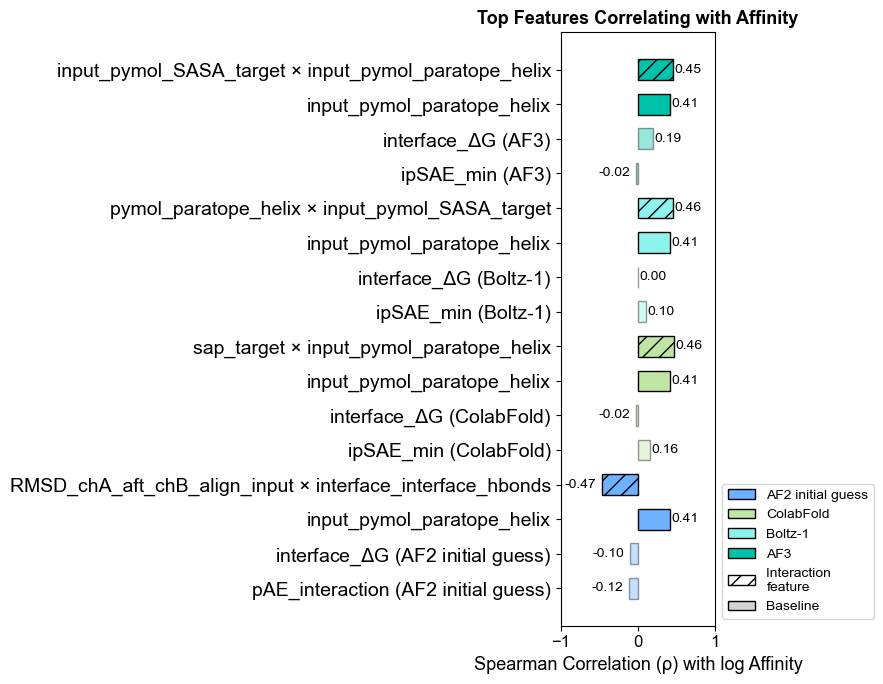

In [11]:
rows = []

# --- Best single features ---
for _, row in top_corr_feats.iterrows():
    model_label = label_map[row['model']]
    feature_name = format_feature_name(row['feature'], model_tags)

    rows.append({
        'feature': feature_name,
        'rho': row['rho'],
        'model': model_label,
        'kind': 'Single'
    })

# --- Best interaction features ---
for _, row in top_corr_inters.iterrows():
    model_label = label_map[row['model']]
    feature_name = format_feature_name(row['feature'], model_tags)

    rows.append({
        'feature': feature_name,
        'rho': row['rho'],
        'model': model_label,
        'kind': 'Interaction'
    })

# --- Baselines ---
for _, row in df_baselines.iterrows():
    model_label = label_map[row['model']]

    fname = row['feature']
    fname = fname.replace(f"{row['model']}_", "")
    fname = fname.replace("rosetta_interface_dG", r'interface_$\Delta$G')
    fname = fname.replace("pae_interaction", 'pAE_interaction')

    rows.append({
        'feature': f"{fname} ({model_label})",  # <- add model to label
        'rho': row['rho'],
        'model': model_label,
        'kind': 'Baseline'
    })

# --- DataFrame ---
df_plot_corr = pd.DataFrame(rows)

# ordered_rows = []



# --- Define order ---
kind_order = {'Interaction': 3, 'Single': 2, 'Baseline': 1}
model_order = {m: i for i, m in enumerate(color_map.keys())}

# --- Add ordering columns ---
df_plot_corr['kind_order'] = df_plot_corr['kind'].map(kind_order)
df_plot_corr['model_order'] = df_plot_corr['model'].map(model_order)

# --- Sort by model first, then kind ---
df_plot_corr = df_plot_corr.sort_values(
    ['model_order', 'kind_order'], 
    ascending=[True, True]
).reset_index(drop=True)

# --- Plot ---
plt.figure(figsize=(9, 7))

y_pos = np.arange(len(df_plot_corr))

for i, (kind, model) in enumerate(zip(df_plot_corr['kind'], df_plot_corr['model'])):

    val = df_plot_corr['rho'].iloc[i]

    if kind == 'Interaction':
        hatch = '//'
        color = color_map[model]
        alpha = 1.0

    elif kind == 'Baseline':
        hatch = ''
        color = color_map[model]
        alpha = 0.4

    else:  # Single
        hatch = ''
        color = color_map[model]
        alpha = 1.0

    plt.barh(
        i,
        val,
        color=color,
        edgecolor='black',
        height=0.6,
        hatch=hatch,
        alpha=alpha
    )

    # --- Value annotation ---
    plt.text(
        val + 0.02 if val > 0 else val - 0.08,
        i,
        f"{val:.2f}",
        va='center',
        ha='left' if val > 0 else 'right',
        fontsize=10
    )

# --- Axes ---
plt.yticks(y_pos, df_plot_corr['feature'])
plt.yticks(fontsize=14)

plt.xlabel('Spearman Correlation (ρ) with log Affinity')
plt.xlim(-1, 1)

plt.title(
    'Top Features Correlating with Affinity',
    fontweight='bold'
)

# --- Legend ---
legend_elements = [
    Patch(facecolor=color_map[label], edgecolor='black', label=label)
    for label in color_map
]

interaction_patch = Patch(
    facecolor='white',
    edgecolor='black',
    hatch='//',
    label="Interaction \nfeature"
)

baseline_patch = Patch(
    facecolor='lightgrey',
    edgecolor='black',
    hatch='',
    label='Baseline'
)

plt.legend(
    handles=legend_elements + [interaction_patch, baseline_patch],
    loc='lower left',
    bbox_to_anchor=(1, 0.0),
    fontsize=10
)

# --- Layout ---
plt.tight_layout()
plt.savefig("../plots/affinity_correlation_by_model_leg.png", dpi=600)
plt.show()

# With inverse

In [14]:
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# -----------------------------
# Prepare affinity data
# -----------------------------

aff_col = "Affinity_nM"

df_aff = df.copy()
df_aff[aff_col] = pd.to_numeric(df_aff[aff_col], errors='coerce')
df_aff = df_aff[df_aff[aff_col].notna()].copy()

df_aff["log_affinity"] = np.log10(df_aff[aff_col])


# -----------------------------
# Clean Spearman (raw + inverse only)
# -----------------------------

def best_spearman(vals, y):
    vals = pd.to_numeric(vals, errors='coerce')
    mask = vals.notna() & y.notna()
    if mask.sum() < 5:
        return np.nan, None

    vals = vals[mask]
    y = y[mask]

    eps = 1e-12

    # --- Raw correlation
    rho_raw, _ = spearmanr(vals, y)

    best_rho = rho_raw
    best_transform = "raw"

    # --- Inverse correlation (if safe)
    if (np.abs(vals) > eps).all():
        inv = 1.0 / vals
        rho_inv, _ = spearmanr(inv, y)

        if abs(rho_inv) > abs(rho_raw):
            best_rho = rho_inv
            best_transform = "inv"

    return best_rho, best_transform


# -----------------------------
# Compute correlations
# -----------------------------

results_corr_feats = []
results_corr_inters = []

for tag in MODEL_TAGS:

    feats = [
        c for c in feature_cols
        if valid_feature_for_model(c, tag, MODEL_TAGS)
    ]
    feats = sorted(set(feats))

    # ---- Single features
    for feat in feats:
        rho, transform = best_spearman(
            df_aff[feat],
            df_aff["log_affinity"]
        )

        results_corr_feats.append({
            'model': tag,
            'feature': feat,
            'rho': rho,
            'transform': transform
        })

    # ---- Interaction features
    for i, f1 in enumerate(feats):
        for f2 in feats[i+1:]:

            v1 = pd.to_numeric(df_aff[f1], errors='coerce')
            v2 = pd.to_numeric(df_aff[f2], errors='coerce')
            inter = v1 * v2

            rho, transform = best_spearman(
                inter,
                df_aff["log_affinity"]
            )

            results_corr_inters.append({
                'model': tag,
                'feature': f"{f1}*{f2}",
                'rho': rho,
                'transform': transform
            })


df_corr_feats = pd.DataFrame(results_corr_feats).dropna()
df_corr_inters = pd.DataFrame(results_corr_inters).dropna()


# -----------------------------
# Select top features per model
# -----------------------------

top_corr_feats = (
    df_corr_feats
    .sort_values('rho', key=lambda x: abs(x), ascending=False)
    .groupby('model')
    .head(1)
    .reset_index(drop=True)
)

top_corr_inters = (
    df_corr_inters
    .sort_values('rho', key=lambda x: abs(x), ascending=False)
    .groupby('model')
    .head(1)
    .reset_index(drop=True)
)


# -----------------------------
# Helper for pretty feature formatting
# -----------------------------

def format_feature_for_plot(feat, transform):
    """
    Formats both single and interaction features nicely.
    Adds ⁻¹ if inverse was selected.
    """

    if "*" in feat:
        f1, f2 = feat.split("*")
        f1_fmt = format_feature_name(f1, model_tags)
        f2_fmt = format_feature_name(f2, model_tags)
        base = f"{f1_fmt} × {f2_fmt}"
    else:
        base = format_feature_name(feat, model_tags)

    if transform == "inv":
        return f"{base}⁻¹"
    else:
        return base




/tmp/ipykernel_3884239/348996063.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_raw, _ = spearmanr(vals, y)
/tmp/ipykernel_3884239/348996063.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_raw, _ = spearmanr(vals, y)
/tmp/ipykernel_3884239/348996063.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_raw, _ = spearmanr(vals, y)


/tmp/ipykernel_3884239/3054348271.py:96: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


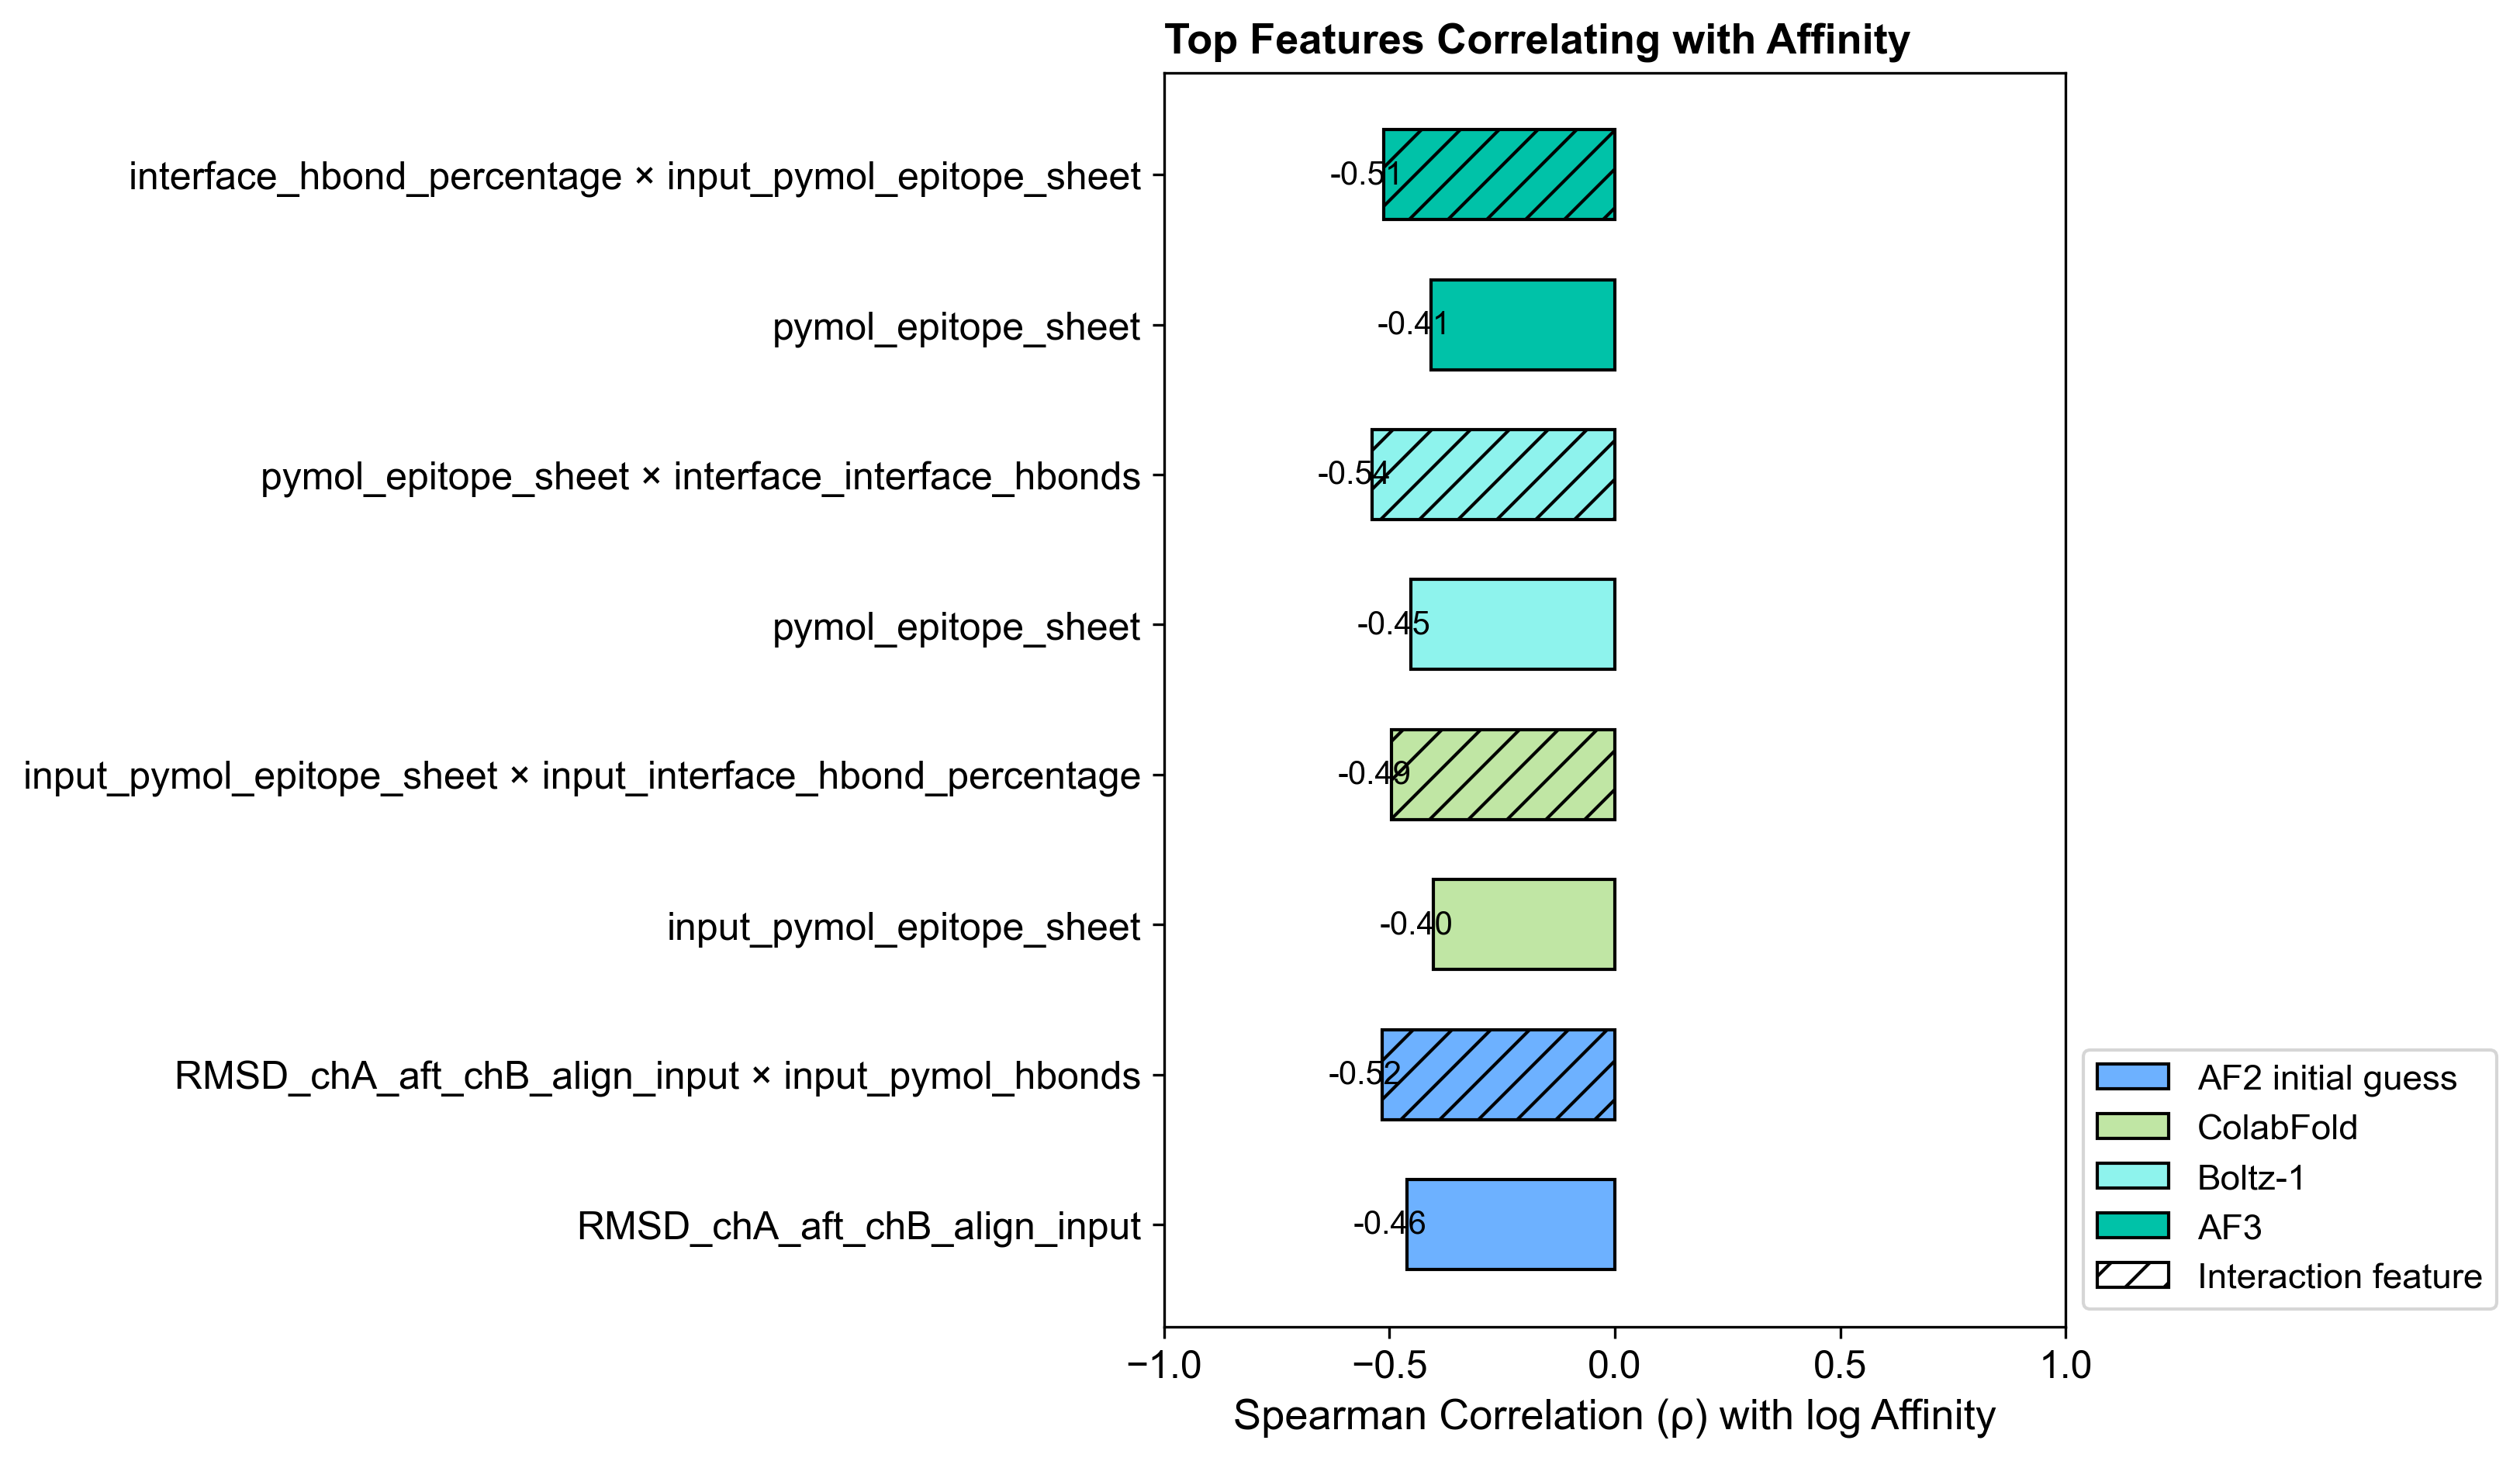

In [15]:
# -----------------------------
# Prepare plotting dataframe
# -----------------------------

rows = []

for _, row in top_corr_feats.iterrows():
    model_label = label_map[row['model']]

    rows.append({
        'feature': format_feature_for_plot(row['feature'], row['transform']),
        'rho': row['rho'],
        'model': model_label,
        'kind': 'Single'
    })

for _, row in top_corr_inters.iterrows():
    model_label = label_map[row['model']]

    rows.append({
        'feature': format_feature_for_plot(row['feature'], row['transform']),
        'rho': row['rho'],
        'model': model_label,
        'kind': 'Interaction'
    })

df_plot_corr = pd.DataFrame(rows)


# -----------------------------
# Ordering
# -----------------------------

order_map = {name: i for i, name in enumerate(color_map.keys())}
kind_order = {'Single': 0, 'Interaction': 1}

df_plot_corr['order'] = df_plot_corr['model'].map(order_map)
df_plot_corr['kind_order'] = df_plot_corr['kind'].map(kind_order)

df_plot_corr = df_plot_corr.sort_values(['order', 'kind_order'])


# -----------------------------
# Plot
# -----------------------------

plt.figure(dpi=300, figsize=(5, 7))

y_pos = np.arange(len(df_plot_corr))
bar_colors = [color_map[model] for model in df_plot_corr['model']]

for i, (kind, color) in enumerate(zip(df_plot_corr['kind'], bar_colors)):

    hatch = '//' if kind == 'Interaction' else ''
    val = df_plot_corr['rho'].iloc[i]

    plt.barh(i, val,
             color=color,
             edgecolor='black',
             height=0.6,
             hatch=hatch)

    plt.text(val + 0.02 if val > 0 else val - 0.12,
             i,
             f"{val:.2f}",
             va='center',
             fontsize=10)

plt.yticks(y_pos, df_plot_corr['feature'])
plt.xlabel('Spearman Correlation (ρ) with log Affinity')
plt.xlim(-1, 1)
plt.title('Top Features Correlating with Affinity',
          loc='left',
          fontweight='bold')


# -----------------------------
# Legend
# -----------------------------

legend_elements = [
    Patch(facecolor=color_map[label], edgecolor='black', label=label)
    for label in color_map
]

interaction_patch = Patch(facecolor='white',
                          edgecolor='black',
                          hatch='//',
                          label="Interaction feature")

plt.legend(handles=legend_elements + [interaction_patch],
           loc='lower left',
           bbox_to_anchor=(1, 0.0),
           fontsize=11)

plt.tight_layout()
plt.show()

# after subsetting with ipSAE_min > 0.6

77/114 rows passed AF3_ipSAE_min > 0.6 filter


/tmp/ipykernel_3884239/483157149.py:35: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_high, _ = spearmanr(vals, y)
/tmp/ipykernel_3884239/483157149.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_low, _  = spearmanr(-vals, y)
/tmp/ipykernel_3884239/483157149.py:35: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_high, _ = spearmanr(vals, y)
/tmp/ipykernel_3884239/483157149.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_low, _  = spearmanr(-vals, y)
/tmp/ipykernel_3884239/483157149.py:35: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_high, _ = spearmanr(vals, y)
/tmp/ipykernel_3884239/483157149.py:36: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho_low, _  = spe

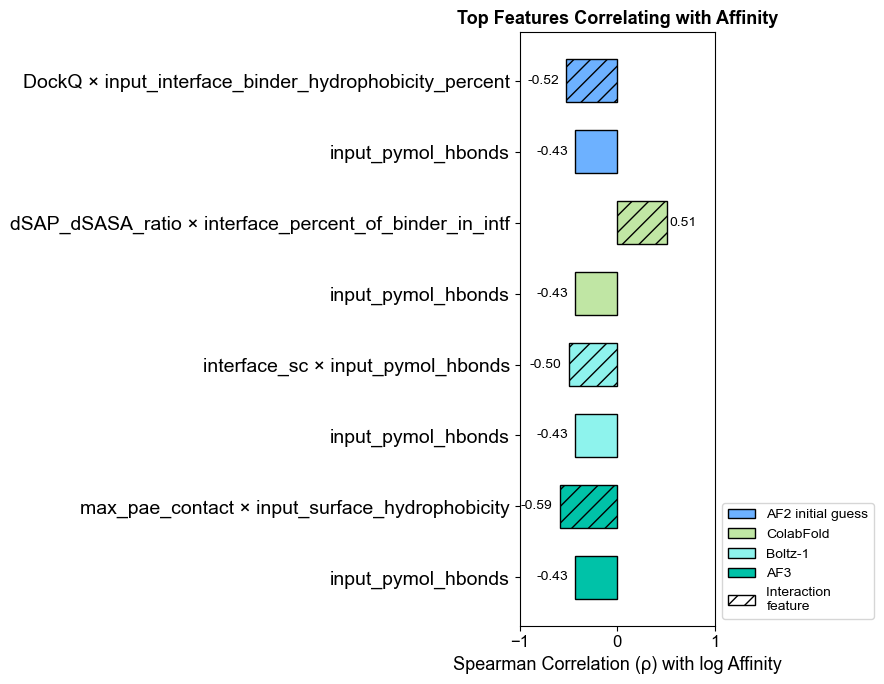

In [16]:
from scipy.stats import spearmanr
import numpy as np

# --- Prepare affinity data ---
aff_col = "Affinity_nM"  # CHANGE if needed

df_aff = df.copy()
df_aff[aff_col] = pd.to_numeric(df_aff[aff_col], errors='coerce')
df_aff = df_aff[df_aff[aff_col].notna()].copy()

# log-transform
df_aff["log_affinity"] = np.log10(df_aff[aff_col])



# --- Filter by AF3_ipSAE_min ---
threshold = 0.6
df_filtered = df_aff[df_aff['af3_ipSAE_min'] > threshold].copy()

n_total = len(df_aff)
n_passed = len(df_filtered)
print(f"{n_passed}/{n_total} rows passed AF3_ipSAE_min > {threshold} filter")

df_aff=df_filtered.copy()

def best_spearman_and_direction(vals, y):
    vals = pd.to_numeric(vals, errors='coerce')
    mask = vals.notna() & y.notna()
    if mask.sum() < 5:
        return np.nan, None

    vals = vals[mask]
    y = y[mask]

    rho_high, _ = spearmanr(vals, y)
    rho_low, _  = spearmanr(-vals, y)

    if abs(rho_high) >= abs(rho_low):
        return rho_high, False
    else:
        return rho_low, True


results_corr_feats = []
results_corr_inters = []

for tag in MODEL_TAGS:

    feats = [
        c for c in feature_cols
        if valid_feature_for_model(c, tag, MODEL_TAGS)
    ]
    feats = sorted(set(feats))

    for feat in feats:
        rho, is_lower = best_spearman_and_direction(
            df_aff[feat],
            df_aff["log_affinity"]
        )
        results_corr_feats.append({
            'model': tag,
            'feature': feat,
            'rho': rho,
            'lower_is_better': is_lower
        })

    for i, f1 in enumerate(feats):
        for f2 in feats[i+1:]:
            v1 = pd.to_numeric(df_aff[f1], errors='coerce')
            v2 = pd.to_numeric(df_aff[f2], errors='coerce')
            inter = v1 * v2

            rho, is_lower = best_spearman_and_direction(
                inter,
                df_aff["log_affinity"]
            )

            results_corr_inters.append({
                'model': tag,
                'feature': f"{f1}*{f2}",
                'rho': rho,
                'lower_is_better': is_lower
            })

df_corr_feats = pd.DataFrame(results_corr_feats).dropna()
df_corr_inters = pd.DataFrame(results_corr_inters).dropna()

top_corr_feats = (
    df_corr_feats
    .sort_values('rho', key=lambda x: abs(x), ascending=False)
    .groupby('model')
    .head(1)
    .reset_index(drop=True)
)

top_corr_inters = (
    df_corr_inters
    .sort_values('rho', key=lambda x: abs(x), ascending=False)
    .groupby('model')
    .head(1)
    .reset_index(drop=True)
)


rows = []

for _, row in top_corr_feats.iterrows():
    model_label = label_map[row['model']]
    feature_name = format_feature_name(row['feature'], model_tags)
    rows.append({
        'feature': feature_name,
        'rho': row['rho'],
        'model': model_label,
        'kind': 'Single'
    })

for _, row in top_corr_inters.iterrows():
    model_label = label_map[row['model']]
    feature_name = format_feature_name(row['feature'], model_tags)
    rows.append({
        'feature': feature_name,
        'rho': row['rho'],
        'model': model_label,
        'kind': 'Interaction'
    })

df_plot_corr = pd.DataFrame(rows)

order_map = {name: -i for i, name in enumerate(color_map.keys())}
kind_order = {'Single': 0, 'Interaction': 1}
df_plot_corr['order'] = df_plot_corr['model'].map(order_map)
df_plot_corr['kind_order'] = df_plot_corr['kind'].map(kind_order)
df_plot_corr = df_plot_corr.sort_values(['order', 'kind_order'])

plt.figure( figsize=(9, 7))
y_pos = np.arange(len(df_plot_corr))
bar_colors = [color_map[model] for model in df_plot_corr['model']]

for i, (kind, color) in enumerate(zip(df_plot_corr['kind'], bar_colors)):
    hatch = '//' if kind == 'Interaction' else ''
    val = df_plot_corr['rho'].iloc[i]

    plt.barh(i, val, color=color, edgecolor='black',
             height=0.6, hatch=hatch)

    plt.text(val + 0.02 if val > 0 else val - 0.4,
             i,
             f"{val:.2f}",
             va='center',
             fontsize=10)

plt.yticks(y_pos, df_plot_corr['feature'])
plt.yticks(fontsize=14)
plt.xlabel('Spearman Correlation (ρ) with log Affinity')
plt.xlim(-1, 1)
plt.title('Top Features Correlating with Affinity',
          #loc='left',
          fontweight='bold')

legend_elements = [
    Patch(facecolor=color_map[label], edgecolor='black', label=label)
    for label in color_map
]
interaction_patch = Patch(facecolor='white',
                          edgecolor='black',
                          hatch='//',
                          label="Interaction \nfeature")

plt.legend(handles=legend_elements + [interaction_patch],
           loc='lower left',
           bbox_to_anchor=(1, 0.0),
           fontsize=10)

plt.tight_layout()
plt.savefig("../plots/affinity_correlation_by_model2.png",dpi=600)
plt.show()



In [17]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def plot_metrics_vs_affinity(df, metrics, affinity_col="Affinity_nM",
                             log_transform=True,
                             color_by_ipsae=False,
                             ipsae_col="af3_ipSAE_min",
                             ipsae_cutoff=0.6,
                             figsize=(5,5)):

    """
    Plots scatter of metric vs log affinity.

    Options:
    - color_by_ipsae=False : color by target_id
    - color_by_ipsae=True  : color by ipsae cutoff

    Supports:
        A*B
        A/B
        A*B/C
        A/B/C
    """

    df = df.copy()
    df[affinity_col] = pd.to_numeric(df[affinity_col], errors='coerce')
    df = df[df[affinity_col].notna()].copy()

    if log_transform:
        df["log_affinity"] = np.log10(df[affinity_col])
        y_col = "log_affinity"
        y_label = "log10(Affinity)"
    else:
        y_col = affinity_col
        y_label = affinity_col

    if "target_id" not in df.columns:
        raise ValueError("DataFrame must contain 'target_id' column")

    # -----------------------------
    # Color setup
    # -----------------------------

    if color_by_ipsae:

        if ipsae_col not in df.columns:
            raise ValueError(f"{ipsae_col} not found in dataframe")

        df["ipsae_pass"] = pd.to_numeric(df[ipsae_col], errors="coerce") > ipsae_cutoff

        color_map = {
            True: "#2A9D8F",   # teal
            False: "#bdbdbd"   # grey
        }

    else:
        targets = df["target_id"].dropna().unique()
        cmap = plt.cm.get_cmap("tab20", len(targets))
        color_dict = {t: cmap(i) for i, t in enumerate(targets)}

    # -----------------------------
    # Loop metrics
    # -----------------------------

    for metric in metrics:

        try:
            mult_parts = [m.strip() for m in metric.split("*")]

            x = pd.Series(1.0, index=df.index)

            for part in mult_parts:

                div_parts = [d.strip() for d in part.split("/")]

                numerator = div_parts[0]
                if numerator not in df.columns:
                    raise KeyError(numerator)

                term = pd.to_numeric(df[numerator], errors="coerce")

                for denom in div_parts[1:]:

                    if denom not in df.columns:
                        raise KeyError(denom)

                    denom_vals = pd.to_numeric(df[denom], errors="coerce")

                    eps = 1e-12
                    denom_vals = denom_vals.where(np.abs(denom_vals) > eps)

                    term = term / denom_vals

                x *= term

        except KeyError as e:
            print(f"Skipping {metric} (missing column: {e})")
            continue

        x_all = x
        y_all = df[y_col]

        mask = x_all.notna() & y_all.notna()

        if mask.sum() < 5:
            print(f"Skipping {metric} (too few valid points)")
            continue

        x_all = x_all[mask]
        y_all = y_all[mask]
        df_valid = df.loc[mask]

        rho, pval = spearmanr(x_all, y_all)
        fig, ax = plt.subplots(figsize=figsize)

        # Example: replace plt.scatter with ax.scatter
        if color_by_ipsae:
            for status in [False, True]:
                submask = df_valid["ipsae_pass"] == status
                if submask.sum() == 0:
                    continue
                label = f"{ipsae_col} > {ipsae_cutoff}" if status else f"{ipsae_col} ≤ {ipsae_cutoff}"
                ax.scatter(
                    x_all[submask],
                    y_all[submask],
                    label=label,
                    alpha=0.7,
                    edgecolor='black',
                    linewidth=0.3,
                    color=color_map[status]
                )
        else:
            for target in df_valid["target_id"].unique():
                submask = df_valid["target_id"] == target
                ax.scatter(
                    x_all[submask],
                    y_all[submask],
                    label=str(target),
                    alpha=0.7,
                    edgecolor='black',
                    linewidth=0.3,
                    color=color_dict[target]
                )

        # Labels
        ax.set_xlabel(metric.replace("*"," x "),fontsize=11)
        ax.set_ylabel(y_label,fontsize=11)
        ax.set_title(metric.replace("*"," x "), fontweight='bold',fontsize=11)

        ax.text(
            0.05, 0.95,
            f"Spearman ρ = {rho:.2f}\np = {pval:.2e}",
            transform=ax.transAxes,
            verticalalignment='top',
            fontsize=10,
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none')
        )

        # Legend
        ax.legend(
            fontsize=8 if color_by_ipsae else 6,
            loc="lower left" if color_by_ipsae else "center left",
            bbox_to_anchor=(1.02, 0.5) if not color_by_ipsae else None,
            #borderaxespad=0.0
        )

        # Ensure tight layout respects everything
        fig.tight_layout()

        # Save figure explicitly from fig
        if color_by_ipsae:
            fig.savefig(f"../plots/{metric.replace('/', ' div ')}_affinity.png", dpi=600)
        else:
            fig.savefig(f"../plots/affinity_{metric.replace('/', ' div ')}_col_target.png", dpi=600)

        plt.show()

/tmp/ipykernel_3884239/2503775085.py:61: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(targets))


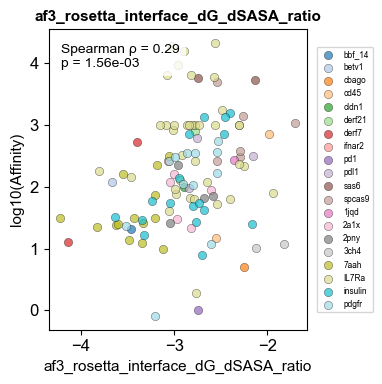

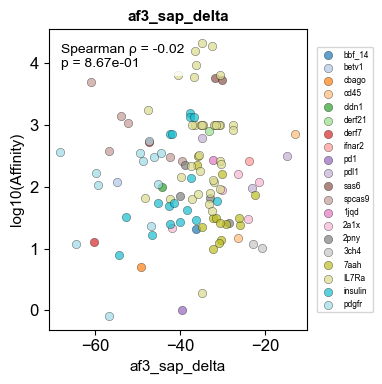

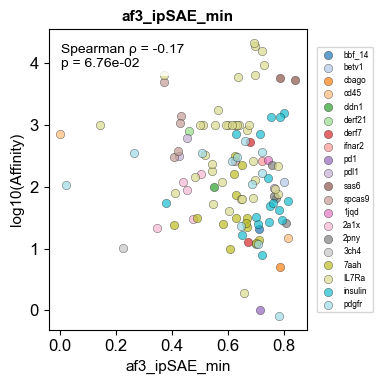

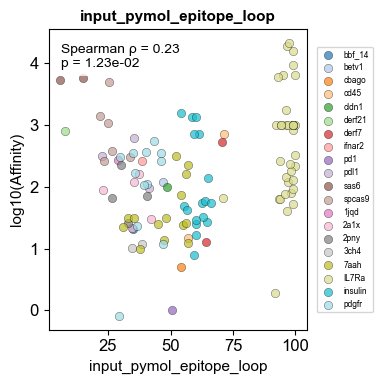

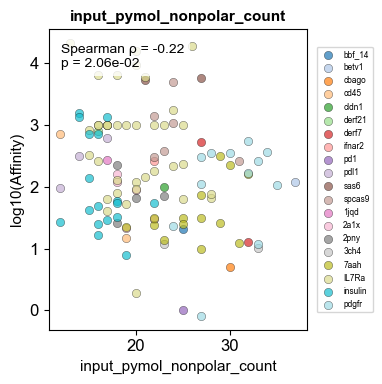

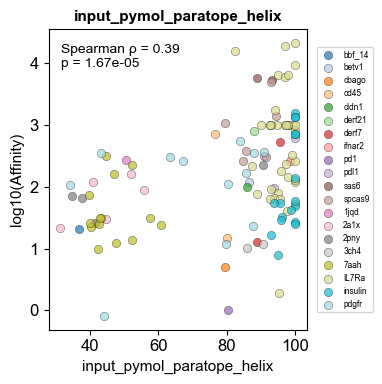

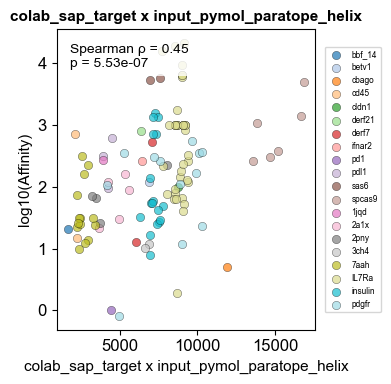

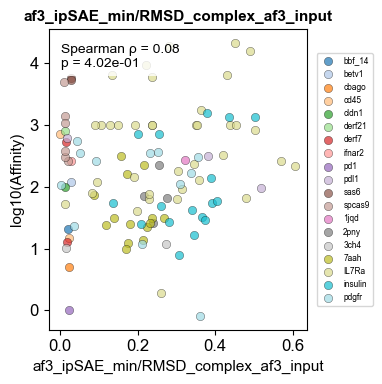

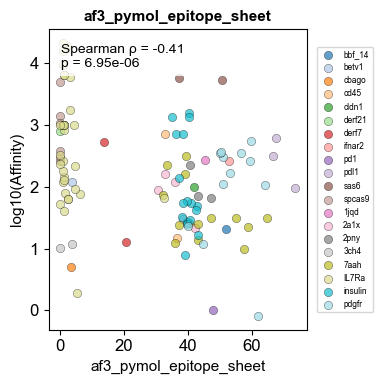

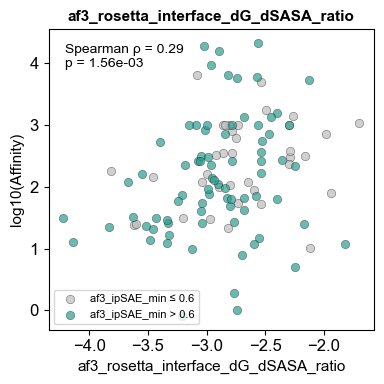

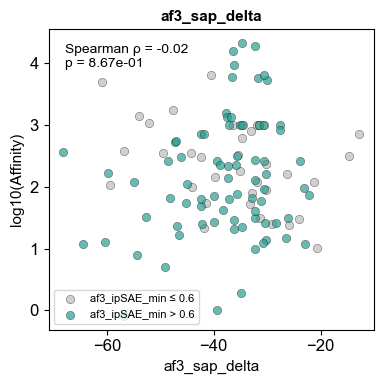

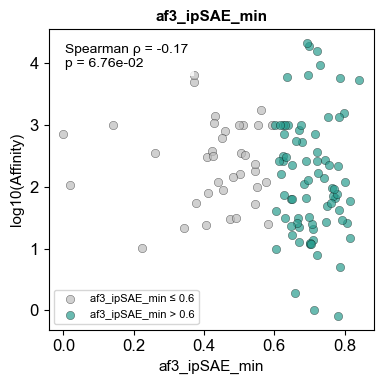

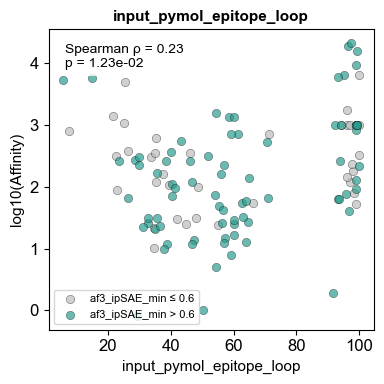

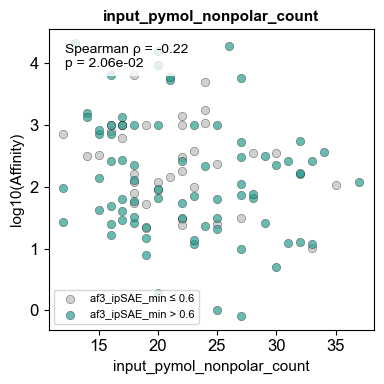

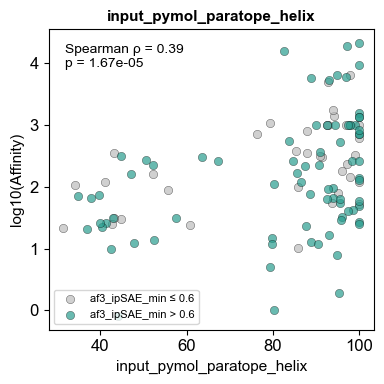

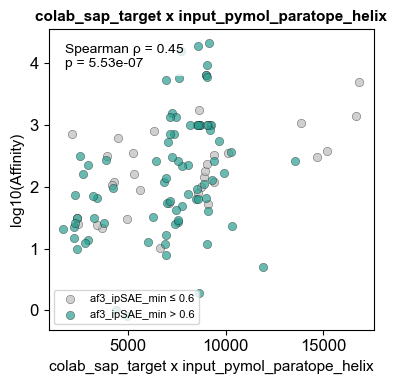

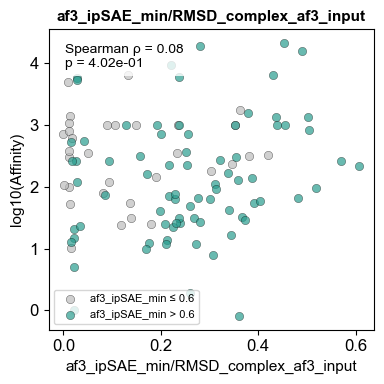

In [33]:


model_tags = list(label_map.keys())

plot_metrics_vs_affinity(
    df,
    metrics=[
        "af3_rosetta_interface_dG_dSASA_ratio",
        "af3_sap_delta",
        "af3_ipSAE_min",
        "input_pymol_epitope_loop",
            "input_pymol_nonpolar_count",
            "input_pymol_paratope_helix",
            "colab_sap_target*input_pymol_paratope_helix",
            "af3_ipSAE_min/RMSD_complex_af3_input",
            "af3_pymol_epitope_sheet"
            
    ],
    affinity_col="Affinity_nM",
    figsize=(4,4)


)


plot_metrics_vs_affinity(
    df,
    metrics=[
        "af3_rosetta_interface_dG_dSASA_ratio",
        "af3_sap_delta",
        "af3_ipSAE_min",
        "input_pymol_epitope_loop",
            "input_pymol_nonpolar_count",
            "input_pymol_paratope_helix",
            "colab_sap_target*input_pymol_paratope_helix",
            "af3_ipSAE_min/RMSD_complex_af3_input"
    ],
    affinity_col="Affinity_nM",
    color_by_ipsae=True,
    figsize=(4,4)


)


# Par target calculations

In [19]:
from scipy.stats import spearmanr
import numpy as np
import pandas as pd
from tqdm import tqdm

MIN_PER_TARGET = 5
DROP_SMALL_TARGETS = True

df = df_aff.copy()  # using your affinity-prepared df

if DROP_SMALL_TARGETS:
    valid_targets = []
    for tid, group in df.groupby('target_id'):
        if group.shape[0] >= MIN_PER_TARGET:
            valid_targets.append(tid)

    print(f"Keeping {len(valid_targets)} targets with ≥{MIN_PER_TARGET} samples")
    df = df[df['target_id'].isin(valid_targets)].copy()


feature_cols = [c for c in df.columns if c not in ["Affinity_nM", "log_affinity"]]

all_metrics = []

for tag in MODEL_TAGS:

    feats = [
        c for c in feature_cols
        if valid_feature_for_model(c, tag, MODEL_TAGS)
    ]
    feats = sorted(set(feats))

    # Singles
    for feat in feats:
        all_metrics.append((feat, False, tag))

    # Interactions
    for i, f1 in enumerate(feats):
        for f2 in feats[i+1:]:
            name = f"{f1}*{f2}"
            all_metrics.append((name, True, tag))



rows = []

for feat, is_inter, tag in tqdm(all_metrics, desc="Computing per-target Spearman"):

    rho_high_list = []
    rho_low_list = []
    per_target_data = []

    for tid, group in df.groupby("target_id"):

        y = group["log_affinity"]

        if is_inter:
            f1, f2 = feat.split("*")
            x = (
                pd.to_numeric(group[f1], errors='coerce') *
                pd.to_numeric(group[f2], errors='coerce')
            )
        else:
            x = pd.to_numeric(group[feat], errors='coerce')

        mask = x.notna() & y.notna()
        if mask.sum() < 4:
            continue

        x = x[mask]
        y = y[mask]

        if x.nunique() <= 1:
            continue

        rho_high, _ = spearmanr(x, y)
        rho_low, _  = spearmanr(-x, y)

        rho_high_list.append(rho_high)
        rho_low_list.append(rho_low)

        per_target_data.append((tid, rho_high, rho_low))

    if len(rho_high_list) == 0:
        continue

    # --- Decide global direction ---
    median_high = np.nanmedian(np.abs(rho_high_list))
    median_low  = np.nanmedian(np.abs(rho_low_list))

    lower_is_better = median_low > median_high

    # --- Store per-target rho using chosen direction ---
    for tid, rho_high, rho_low in per_target_data:
        rho = rho_low if lower_is_better else rho_high

        rows.append({
            "feature": feat,
            "is_interaction": is_inter,
            "model_tag": tag,
            "target_id": tid,
            "rho": rho,
            "lower_is_better": lower_is_better,
        })

rho_per_target_df = pd.DataFrame(rows)


summary_df = (
    rho_per_target_df
    .groupby(["feature", "is_interaction", "model_tag"])
    .agg(
        median_rho=("rho", "median"),
        q25=("rho", lambda x: np.percentile(x, 25)),
        q75=("rho", lambda x: np.percentile(x, 75)),
    )
    .reset_index()
)

Keeping 4 targets with ≥5 samples


Computing per-target Spearman:  72%|███████▏  | 14383/19993 [01:26<00:33, 166.59it/s]


KeyboardInterrupt: 

In [ ]:
summary_df["abs_median"] = summary_df["median_rho"].abs()

top_summary = (
    summary_df
    .sort_values("abs_median", ascending=False)
    .groupby("model_tag")
    .head(1)
    .reset_index(drop=True)
)

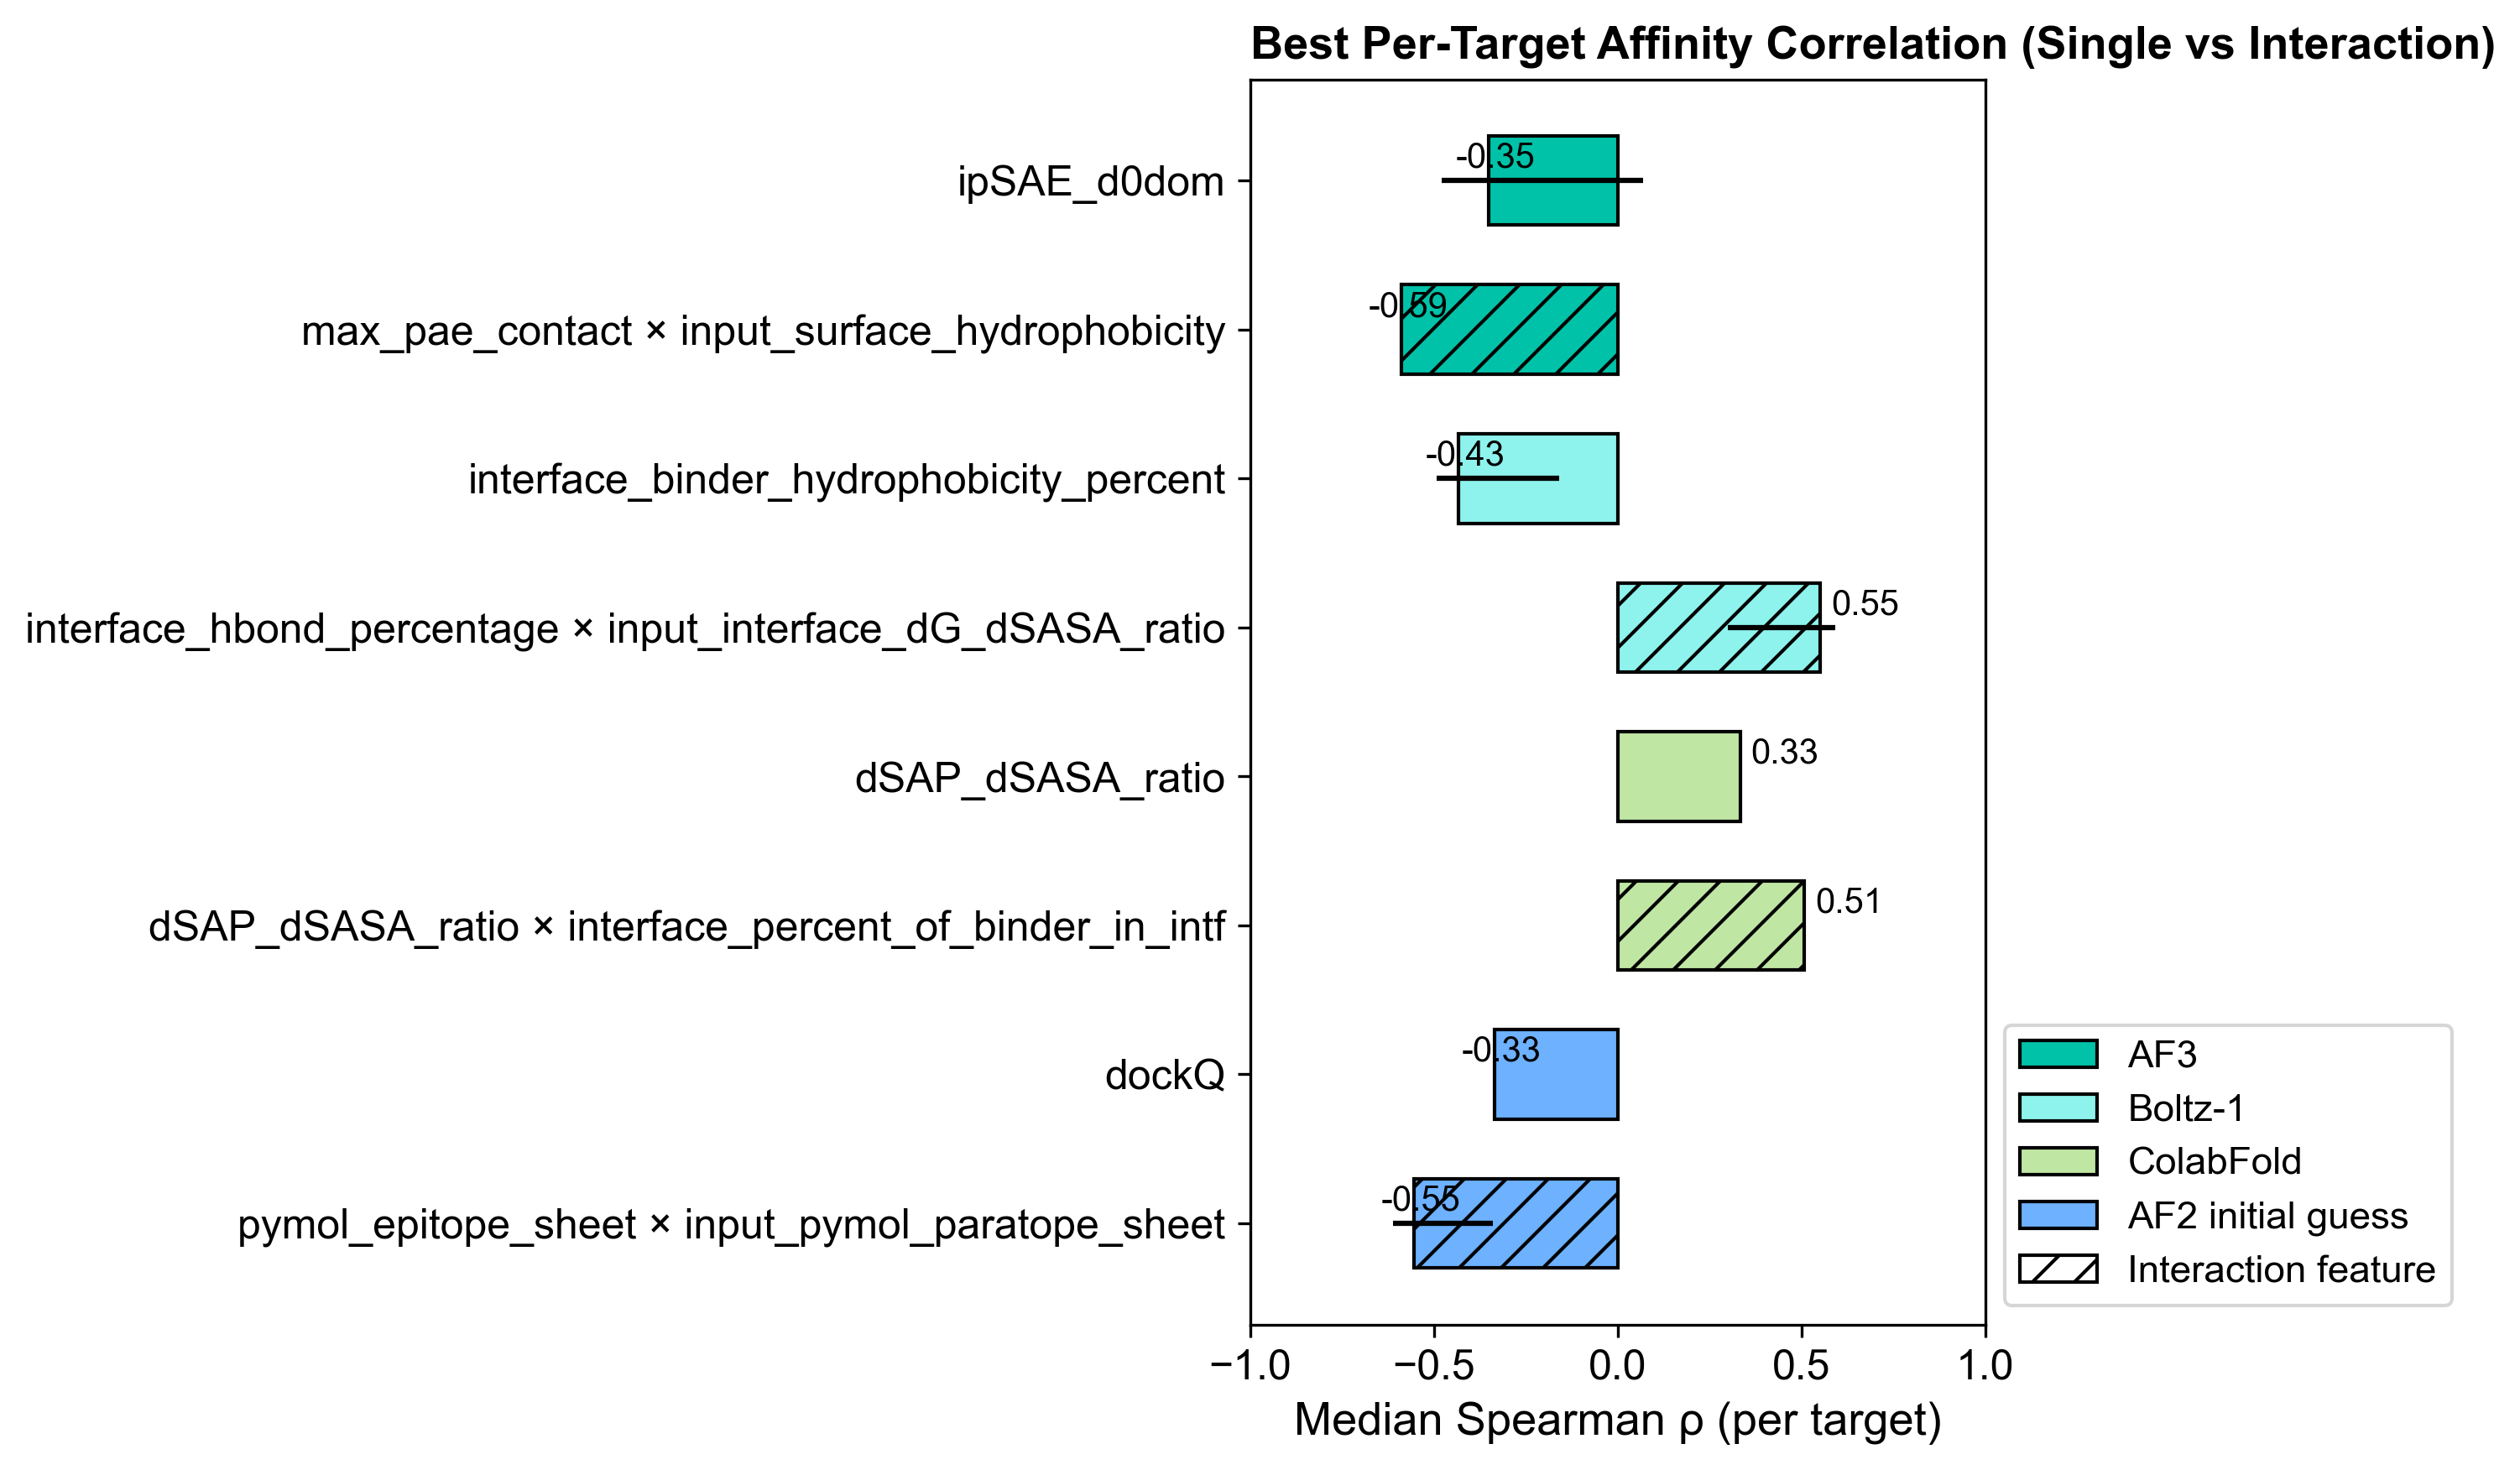

In [ ]:
# Use your mappings
label_map = {
        'af3':    'AF3',
   

    'boltz': 'Boltz-1',
    'colab':  'ColabFold',
     'af2':    'AF2 initial guess',
}
color_map = {'AF3':               '#00c2a8',

     'Boltz-1':           '#8EF3ED',
    'ColabFold':         '#C0E6A4',

       'AF2 initial guess': '#6db1ff'
    }
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# --- Select best single + interaction per model ---
best_per_model = (
    summary_df
    .copy()
    .sort_values('median_rho', key=lambda x: x.abs(), ascending=False)
    .groupby(['model_tag', 'is_interaction'])
    .head(1)
    .reset_index(drop=True)
)

# Format labels
best_per_model['feature_label'] = best_per_model['feature'].apply(
    lambda x: format_feature_name(x, MODEL_TAGS)
)
best_per_model['model_label'] = best_per_model['model_tag'].map(label_map)

# --- Sort by label_map order and interaction ---
order_map = {name: -i for i, name in enumerate(label_map.values())}
best_per_model = best_per_model.sort_values(['model_label', 'is_interaction'], 
                                            key=lambda x: x.map(order_map))

plt.figure(figsize=(10, 6), dpi=300)
y_pos = range(len(best_per_model))

for i, row in enumerate(best_per_model.itertuples()):
    median = row.median_rho
    q25 = row.q25
    q75 = row.q75
    color = color_map[row.model_label]
    hatch = '//' if row.is_interaction else ''

    # Bar with IQR as xerr
    plt.barh(i, median, xerr=[[median - q25], [q75 - median]],
             color=color, edgecolor='black', height=0.6, hatch=hatch)

    # Annotate median value with extra padding
    pad = 0.03  # extra spacing
    x_text = median + pad if median >= 0 else median - pad*3
    plt.text(x_text, i+0.15, f"{median:.2f}", va='center', fontsize=10)

plt.yticks(y_pos, best_per_model['feature_label'])
plt.xlabel("Median Spearman ρ (per target)")
plt.xlim(-1, 1)
plt.title("Best Per-Target Affinity Correlation (Single vs Interaction)", loc='left', fontweight='bold')

# Legend
legend_elements = [Patch(facecolor=color_map[label], edgecolor='black', label=label)
                   for label in color_map]
interaction_patch = Patch(facecolor='white', edgecolor='black', hatch='//', label='Interaction feature')
plt.legend(handles=legend_elements + [interaction_patch], bbox_to_anchor=(1, 0), loc='lower left')

plt.tight_layout()
plt.show()